# QM8: Standard-SEG vs TAME (Tri-Modal MoE)

Dieses Notebook vergleicht auf **demselben QM8 Split** drei Modelle im **echten Multi-Task Regression Setup (16 Tasks)**:
1. **Standard SEG** (Graph + Text)
2. **TAME** (Graph + Text + RDKit-Deskriptoren mit element-wise MoE-Gating)
3. **TAME (Stage-1 init)**: TAME mit Stage-1-pretrained Cheb-Encoder

Training erfolgt auf den normalisierten Targets aus DeepChem; Evaluation erfolgt auf inverse-transformierten Originalwerten.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors

import deepchem as dc

RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'models').exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from models.seg_predictor import SEGPredictor, SEGPredictorConfig
from models.tame_predictor import TAMEPredictor, TAMEPredictorConfig
from utils.embedding_cache import EfficientEmbeddingCache

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

print(f'Workspace root: {workspace_root}')
print(f'Device: {device}')

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Workspace root: C:\Users\robsc\Home\Dev\molfusion2
Device: cuda


In [2]:
def regression_metrics_multitask(y_true, y_pred, observed_mask=None):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)

    if y_true.ndim != 2 or y_pred.ndim != 2:
        raise ValueError('y_true and y_pred must be 2D arrays')
    if y_true.shape != y_pred.shape:
        raise ValueError('Shape mismatch between y_true and y_pred')

    if observed_mask is None:
        observed_mask = np.isfinite(y_true) & np.isfinite(y_pred)
    else:
        observed_mask = np.asarray(observed_mask, dtype=bool) & np.isfinite(y_true) & np.isfinite(y_pred)

    n_tasks = y_true.shape[1]
    maes, rmses = [], []

    for t in range(n_tasks):
        m = observed_mask[:, t]
        if int(m.sum()) == 0:
            maes.append(np.nan)
            rmses.append(np.nan)
            continue
        err = y_pred[m, t] - y_true[m, t]
        maes.append(float(np.mean(np.abs(err))))
        rmses.append(float(np.sqrt(np.mean(err * err))))

    return {
        'macro_mae': float(np.nanmean(maes)),
        'macro_rmse': float(np.nanmean(rmses)),
        'n_tasks_eval': int(np.sum(np.isfinite(maes))),
        'per_task_mae': np.asarray(maes, dtype=np.float32),
        'per_task_rmse': np.asarray(rmses, dtype=np.float32),
    }

def per_task_regression_table(task_names, y_true, y_pred, observed_mask=None):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    if observed_mask is None:
        observed_mask = np.isfinite(y_true) & np.isfinite(y_pred)
    else:
        observed_mask = np.asarray(observed_mask, dtype=bool) & np.isfinite(y_true) & np.isfinite(y_pred)

    rows = []
    for t, name in enumerate(task_names):
        m = observed_mask[:, t]
        if int(m.sum()) == 0:
            rows.append({'task': name, 'n_obs': 0, 'mae': np.nan, 'rmse': np.nan})
            continue
        err = y_pred[m, t] - y_true[m, t]
        rows.append({
            'task': name,
            'n_obs': int(m.sum()),
            'mae': float(np.mean(np.abs(err))),
            'rmse': float(np.sqrt(np.mean(err * err))),
        })
    return pd.DataFrame(rows)

def rdkit_descriptor_matrix(smiles_list):
    desc_names = [name for name, _ in Descriptors.descList]
    n_desc = len(desc_names)
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append(np.full((n_desc,), np.nan, dtype=np.float32))
            continue
        all_desc = Descriptors.CalcMolDescriptors(mol)
        row = []
        for name in desc_names:
            try:
                row.append(float(all_desc.get(name, np.nan)))
            except Exception:
                row.append(np.nan)
        rows.append(np.asarray(row, dtype=np.float32))
    return np.vstack(rows).astype(np.float32), desc_names

def impute_with_train_median(train_X, valid_X, test_X):
    med = np.nanmedian(train_X, axis=0)
    med = np.where(np.isfinite(med), med, 0.0).astype(np.float32)

    def _imp(X):
        X = np.asarray(X, dtype=np.float32)
        mask = ~np.isfinite(X)
        if mask.any():
            X = X.copy()
            X[mask] = np.take(med, np.where(mask)[1])
        return X

    return _imp(train_X), _imp(valid_X), _imp(test_X)

In [3]:
SPLIT_TYPE = 'random'
tasks, datasets, transformers = dc.molnet.load_qm8(
    featurizer='ECFP',
    splitter='scaffold' if SPLIT_TYPE == 'scaffold' else 'random',
)
train_dc, valid_dc, test_dc = datasets

NUM_TASKS = int(len(tasks))

train_smiles = list(train_dc.ids)
valid_smiles = list(valid_dc.ids)
test_smiles = list(test_dc.ids)

# DeepChem QM8 labels are normalized by default (NormalizationTransformer).
train_y_norm = np.asarray(train_dc.y, dtype=np.float32)
valid_y_norm = np.asarray(valid_dc.y, dtype=np.float32)
test_y_norm = np.asarray(test_dc.y, dtype=np.float32)

# Keep a copy and invert normalization for reporting in physical units.
train_y_orig = train_y_norm.copy()
valid_y_orig = valid_y_norm.copy()
test_y_orig = test_y_norm.copy()
for transformer in reversed(transformers):
    train_y_orig = transformer.untransform(train_y_orig)
    valid_y_orig = transformer.untransform(valid_y_orig)
    test_y_orig = transformer.untransform(test_y_orig)

train_y_orig = np.asarray(train_y_orig, dtype=np.float32)
valid_y_orig = np.asarray(valid_y_orig, dtype=np.float32)
test_y_orig = np.asarray(test_y_orig, dtype=np.float32)

def untransform_qm8_predictions(pred_norm, transformers):
    pred = np.asarray(pred_norm, dtype=np.float32).copy()
    for transformer in reversed(transformers):
        pred = transformer.untransform(pred)
    return np.asarray(pred, dtype=np.float32)

# Guardrails: training must use normalized labels, evaluation must use untransformed space.
if train_y_norm.shape[1] != NUM_TASKS:
    raise RuntimeError(
        f'Unexpected task dimension: labels={train_y_norm.shape[1]} vs tasks={NUM_TASKS}'
    )
if train_y_norm.shape != train_y_orig.shape:
    raise RuntimeError('Normalized and original-label arrays must have identical shapes.')

norm_mean = np.nanmean(train_y_norm, axis=0)
norm_std = np.nanstd(train_y_norm, axis=0)
print(
    'Normalized-label sanity (train): ',
    f'mean|avg={float(np.nanmean(np.abs(norm_mean))):.4f}, ',
    f'std|avg={float(np.nanmean(norm_std)):.4f}'
)

emb_dir = workspace_root / 'cache' / 'cot_embeddings'
npz_path = emb_dir / 'quantum_fast_text_embeddings_compact.npz'
if not npz_path.exists():
    raise FileNotFoundError(f'Embedding cache not found: {npz_path}')

seg_cache = EfficientEmbeddingCache.load(npz_path)
all_smiles = train_smiles + valid_smiles + test_smiles
all_emb = torch.from_numpy(seg_cache.get_batch(all_smiles)).float()
n_train = len(train_smiles)
n_valid = len(valid_smiles)
train_emb = all_emb[:n_train]
valid_emb = all_emb[n_train:n_train + n_valid]
test_emb = all_emb[n_train + n_valid:]

d_train, desc_names = rdkit_descriptor_matrix(train_smiles)
d_valid, _ = rdkit_descriptor_matrix(valid_smiles)
d_test, _ = rdkit_descriptor_matrix(test_smiles)
d_train, d_valid, d_test = impute_with_train_median(d_train, d_valid, d_test)

print(f'QM8 tasks: {NUM_TASKS}')
print(f'Split: {SPLIT_TYPE} | Sizes -> train={len(train_smiles)}, val={len(valid_smiles)}, test={len(test_smiles)}')
print(f'Train labels shape (normalized): {train_y_norm.shape}')
print(f'Text embedding dim: {all_emb.shape[1]} | Descriptor dim: {d_train.shape[1]}')

Normalized-label sanity (train):  mean|avg=0.0000,  std|avg=1.0000
Loading embeddings from quantum_fast_text_embeddings_compact.npz...
  Loaded 21722 entries, dim=3072
  Memory mode: mapped
QM8 tasks: 16
Split: random | Sizes -> train=17397, val=2175, test=2175
Train labels shape (normalized): (17397, 16)
Text embedding dim: 3072 | Descriptor dim: 217


In [4]:
SEG_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,
    'fusion': 'cross_mha',
    'fusion_dim': 64,
    'fusion_n_heads': 8,
    'text_proj_init': 'xavier',
    'text_proj_init_gain': 0.1,
    'freeze_text_proj': False,
    'dropout': 0.3,
    'fusion_dropout': 0.3,
    'head_dropout': 0.5,
    'head_type': 'mlp',
    'head_hidden_dim': 32,
    'learning_rate': 1e-3,
    'weight_decay': 1e-1,
    'batch_size': 64,
    'num_epochs': 120,
    'patience': 20,
    'scheduler': 'cosine',
    'scheduler_patience': 5,
    'scheduler_factor': 0.5,
    'min_lr': 1e-6,
    'grad_clip': None,
}

TAME_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,
    'fusion_hidden_dim': 64,
    'projection_dropout': 0.25,
    'router_dropout': 0.30,
    'head_hidden_dim': 64,
    'head_dropout': 0.25,
    'learning_rate': 3e-4,
    'weight_decay': 5e-2,
    'gate_balance_weight': 0.005,
    'desc_modality_dropout': 0.15,
    'descriptor_winsorize_lower_q': 0.01,
    'descriptor_winsorize_upper_q': 0.99,
    'descriptor_standardize': True,
    'batch_size': 64,
    'num_epochs': 120,
    'patience': 20,
}

def make_seg_config(text_embedding_dim):
    return SEGPredictorConfig(
        task='regression',
        num_tasks=NUM_TASKS,
        hidden_channels=SEG_FIT_KWARGS['hidden_channels'],
        K=SEG_FIT_KWARGS['K'],
        num_layers=SEG_FIT_KWARGS['num_layers'],
        dropout=SEG_FIT_KWARGS['dropout'],
        pool=SEG_FIT_KWARGS['pool'],
        set2set_processing_steps=SEG_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        text_projection_dim=SEG_FIT_KWARGS['fusion_dim'],
        text_proj_init=SEG_FIT_KWARGS['text_proj_init'],
        text_proj_init_gain=SEG_FIT_KWARGS['text_proj_init_gain'],
        freeze_text_proj=SEG_FIT_KWARGS['freeze_text_proj'],
        fusion=SEG_FIT_KWARGS['fusion'],
        fusion_dim=SEG_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=SEG_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=SEG_FIT_KWARGS['fusion_dropout'],
        head_type=SEG_FIT_KWARGS['head_type'],
        head_hidden_dim=SEG_FIT_KWARGS['head_hidden_dim'],
        head_dropout=SEG_FIT_KWARGS['head_dropout'],
        add_hydrogens=False,
    )

def make_tame_config(text_embedding_dim):
    return TAMEPredictorConfig(
        task='regression',
        num_tasks=NUM_TASKS,
        hidden_channels=TAME_FIT_KWARGS['hidden_channels'],
        K=TAME_FIT_KWARGS['K'],
        num_layers=TAME_FIT_KWARGS['num_layers'],
        pool=TAME_FIT_KWARGS['pool'],
        text_embedding_dim=int(text_embedding_dim),
        fusion_hidden_dim=TAME_FIT_KWARGS['fusion_hidden_dim'],
        projection_dropout=TAME_FIT_KWARGS['projection_dropout'],
        router_dropout=TAME_FIT_KWARGS['router_dropout'],
        head_hidden_dim=TAME_FIT_KWARGS['head_hidden_dim'],
        head_dropout=TAME_FIT_KWARGS['head_dropout'],
        gate_balance_weight=TAME_FIT_KWARGS['gate_balance_weight'],
        desc_modality_dropout=TAME_FIT_KWARGS['desc_modality_dropout'],
        descriptor_winsorize_lower_q=TAME_FIT_KWARGS['descriptor_winsorize_lower_q'],
        descriptor_winsorize_upper_q=TAME_FIT_KWARGS['descriptor_winsorize_upper_q'],
        descriptor_standardize=TAME_FIT_KWARGS['descriptor_standardize'],
        add_hydrogens=False,
    )

def resolve_stage1_pretrain_checkpoint():
    ckpt_dir = workspace_root / 'cache' / 'chemeleon_pretraining'
    alias = ckpt_dir / 'cheb_foundation_pretrain_stage1.pt'
    if not ckpt_dir.exists():
        raise FileNotFoundError(f'Checkpoint directory not found: {ckpt_dir}')

    pattern = (
        f"cheb_foundation_stage1__h{TAME_FIT_KWARGS['hidden_channels']}__"
        f"L{TAME_FIT_KWARGS['num_layers']}__"
        f"K{TAME_FIT_KWARGS['K']}__*.pt"
    )
    candidates = sorted(
        [p for p in ckpt_dir.glob(pattern) if '__fallback__' not in p.name],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if candidates:
        return candidates[0]
    if alias.exists():
        return alias
    raise FileNotFoundError('No stage1 pretraining checkpoint found for TAME init.')

def load_stage1_encoder_state(ckpt_path):
    payload = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    if not isinstance(payload, dict):
        raise RuntimeError('Invalid checkpoint payload format.')

    stage = payload.get('pretraining_stage', None)
    if stage != 'stage1_node':
        raise RuntimeError(
            f"Expected stage1 checkpoint (pretraining_stage='stage1_node'), got {stage!r}"
        )

    model_state = payload.get('model_state_dict', {})
    enc_state = {k.replace('encoder.', '', 1): v for k, v in model_state.items() if k.startswith('encoder.')}
    if not enc_state:
        raise RuntimeError('Checkpoint does not contain encoder.* weights.')

    print(f'Loaded stage1 encoder state from: {Path(ckpt_path).resolve()}')
    return enc_state

In [5]:
seg = SEGPredictor(config=make_seg_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
seg_hist = seg.fit(
    smiles_list=train_smiles,
    labels=train_y_norm.tolist(),
    val_smiles=valid_smiles,
    val_labels=valid_y_norm.tolist(),
    text_embeddings=train_emb,
    val_text_embeddings=valid_emb,
    num_epochs=SEG_FIT_KWARGS['num_epochs'],
    batch_size=SEG_FIT_KWARGS['batch_size'],
    learning_rate=SEG_FIT_KWARGS['learning_rate'],
    weight_decay=SEG_FIT_KWARGS['weight_decay'],
    patience=SEG_FIT_KWARGS['patience'],
    scheduler=SEG_FIT_KWARGS['scheduler'],
    scheduler_patience=SEG_FIT_KWARGS['scheduler_patience'],
    scheduler_factor=SEG_FIT_KWARGS['scheduler_factor'],
    min_lr=SEG_FIT_KWARGS['min_lr'],
    grad_clip=SEG_FIT_KWARGS['grad_clip'],
    seed=seed,
    verbose=True,
)

seg_best_val = float(np.min(seg_hist['val_loss']))
seg_valid_pred_norm = seg.predict_batch(valid_smiles, text_embeddings=valid_emb)
seg_test_pred_norm = seg.predict_batch(test_smiles, text_embeddings=test_emb)

# predict_batch() returns model-space outputs; for QM8 that is normalized space.
seg_valid_pred = untransform_qm8_predictions(seg_valid_pred_norm, transformers)
seg_test_pred = untransform_qm8_predictions(seg_test_pred_norm, transformers)

seg_valid_pred = np.asarray(seg_valid_pred, dtype=np.float32)
seg_test_pred = np.asarray(seg_test_pred, dtype=np.float32)
seg_metrics = regression_metrics_multitask(test_y_orig, seg_test_pred)

print('SEG metrics:', {k: v for k, v in seg_metrics.items() if not k.startswith('per_task_')})

Pre-computing molecular graphs for 17397 molecules...
Pre-computed 17397/17397 valid graphs
Pre-computing molecular graphs for 2175 molecules...
Pre-computed 2175/2175 valid graphs
Training SEGPredictor on 17397 molecules...
Task: regression
Validation set: 2175 molecules
Fusion method: cross_mha
LR scheduler: cosine
Multi-label mode: 16 tasks
Epoch 001 | Train Loss: 0.9684 | Val RMSE: 0.9690 | LR: 1.00e-03
Epoch 005 | Train Loss: 0.9235 | Val RMSE: 0.9553 | LR: 9.96e-04
Epoch 010 | Train Loss: 0.9074 | Val RMSE: 0.9488 | LR: 9.83e-04
Epoch 015 | Train Loss: 0.8888 | Val RMSE: 0.9474 | LR: 9.62e-04
Epoch 020 | Train Loss: 0.8808 | Val RMSE: 0.9424 | LR: 9.33e-04
Epoch 025 | Train Loss: 0.8664 | Val RMSE: 0.9352 | LR: 8.97e-04
Epoch 030 | Train Loss: 0.8562 | Val RMSE: 0.9297 | LR: 8.54e-04
Epoch 035 | Train Loss: 0.8437 | Val RMSE: 0.9224 | LR: 8.05e-04
Epoch 040 | Train Loss: 0.8322 | Val RMSE: 0.9252 | LR: 7.50e-04
Epoch 045 | Train Loss: 0.8245 | Val RMSE: 0.9146 | LR: 6.92e-04
Epoc

In [6]:
# TAME baseline (random initialization)
tame = TAMEPredictor(config=make_tame_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
tame_hist = tame.fit(
    smiles_list=train_smiles,
    labels=train_y_norm.tolist(),
    val_smiles=valid_smiles,
    val_labels=valid_y_norm.tolist(),
    text_embeddings=train_emb.numpy(),
    val_text_embeddings=valid_emb.numpy(),
    descriptor_features=d_train,
    val_descriptor_features=d_valid,
    num_epochs=TAME_FIT_KWARGS['num_epochs'],
    batch_size=TAME_FIT_KWARGS['batch_size'],
    learning_rate=TAME_FIT_KWARGS['learning_rate'],
    weight_decay=TAME_FIT_KWARGS['weight_decay'],
    patience=TAME_FIT_KWARGS['patience'],
    seed=seed,
    verbose=True,
)

tame_best_val = float(np.min(tame_hist['val_loss']))
tame_valid_pred_norm = tame.predict_batch(valid_smiles, text_embeddings=valid_emb.numpy(), descriptor_features=d_valid)
tame_test_pred_norm = tame.predict_batch(test_smiles, text_embeddings=test_emb.numpy(), descriptor_features=d_test)

# predict_batch() returns model-space outputs; for QM8 that is normalized space.
tame_valid_pred = untransform_qm8_predictions(tame_valid_pred_norm, transformers)
tame_test_pred = untransform_qm8_predictions(tame_test_pred_norm, transformers)

tame_valid_pred = np.asarray(tame_valid_pred, dtype=np.float32)
tame_test_pred = np.asarray(tame_test_pred, dtype=np.float32)
tame_metrics = regression_metrics_multitask(test_y_orig, tame_test_pred)

print('TAME metrics:', {k: v for k, v in tame_metrics.items() if not k.startswith('per_task_')})

# TAME with Stage-1-pretrained Cheb encoder initialization
stage1_ckpt = resolve_stage1_pretrain_checkpoint()
stage1_encoder_state = load_stage1_encoder_state(stage1_ckpt)

tame_stage1_init = TAMEPredictor(config=make_tame_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
tame_stage1_hist = tame_stage1_init.fit(
    smiles_list=train_smiles,
    labels=train_y_norm.tolist(),
    val_smiles=valid_smiles,
    val_labels=valid_y_norm.tolist(),
    text_embeddings=train_emb.numpy(),
    val_text_embeddings=valid_emb.numpy(),
    descriptor_features=d_train,
    val_descriptor_features=d_valid,
    num_epochs=TAME_FIT_KWARGS['num_epochs'],
    batch_size=TAME_FIT_KWARGS['batch_size'],
    learning_rate=TAME_FIT_KWARGS['learning_rate'],
    weight_decay=TAME_FIT_KWARGS['weight_decay'],
    patience=TAME_FIT_KWARGS['patience'],
    seed=seed,
    verbose=True,
    init_encoder_state=stage1_encoder_state,
 )

tame_stage1_best_val = float(np.min(tame_stage1_hist['val_loss']))
tame_stage1_valid_pred_norm = tame_stage1_init.predict_batch(
    valid_smiles, text_embeddings=valid_emb.numpy(), descriptor_features=d_valid
)
tame_stage1_test_pred_norm = tame_stage1_init.predict_batch(
    test_smiles, text_embeddings=test_emb.numpy(), descriptor_features=d_test
)

tame_stage1_valid_pred = untransform_qm8_predictions(tame_stage1_valid_pred_norm, transformers)
tame_stage1_test_pred = untransform_qm8_predictions(tame_stage1_test_pred_norm, transformers)

tame_stage1_valid_pred = np.asarray(tame_stage1_valid_pred, dtype=np.float32)
tame_stage1_test_pred = np.asarray(tame_stage1_test_pred, dtype=np.float32)
tame_stage1_metrics = regression_metrics_multitask(test_y_orig, tame_stage1_test_pred)

print('TAME Stage1-init metrics:', {k: v for k, v in tame_stage1_metrics.items() if not k.startswith('per_task_')})

Descriptor preprocessing enabled (winsor q=[0.010, 0.990], standardize=True)
Epoch 001 | train=0.939595 | val=0.905673 | gates G/T/D=0.321/0.320/0.358
Epoch 005 | train=0.859211 | val=0.850296 | gates G/T/D=0.301/0.309/0.389
Epoch 010 | train=0.812605 | val=0.815351 | gates G/T/D=0.314/0.340/0.345
Epoch 015 | train=0.773394 | val=0.802930 | gates G/T/D=0.332/0.341/0.327
Epoch 020 | train=0.749168 | val=0.801515 | gates G/T/D=0.348/0.352/0.300
Epoch 025 | train=0.715594 | val=0.803308 | gates G/T/D=0.363/0.349/0.288
Epoch 030 | train=0.684906 | val=0.782643 | gates G/T/D=0.371/0.345/0.284
Epoch 035 | train=0.657812 | val=0.789763 | gates G/T/D=0.367/0.348/0.285
Epoch 040 | train=0.634033 | val=0.785707 | gates G/T/D=0.380/0.347/0.273
Epoch 045 | train=0.612207 | val=0.777046 | gates G/T/D=0.375/0.353/0.272
Epoch 050 | train=0.593637 | val=0.777836 | gates G/T/D=0.378/0.348/0.275
Epoch 055 | train=0.569429 | val=0.801650 | gates G/T/D=0.376/0.353/0.271
Early stopping at epoch 59
TAME met

,dataset,model,best_val_loss,macro_mae,macro_rmse,n_tasks_eval
0,qm8,tame_trimodal_moe,0.769878,0.032323,0.049655,16
1,qm8,tame_trimodal_moe_stage1_init,0.794674,0.032831,0.051086,16
2,qm8,seg_standard,0.787472,0.033583,0.050342,16


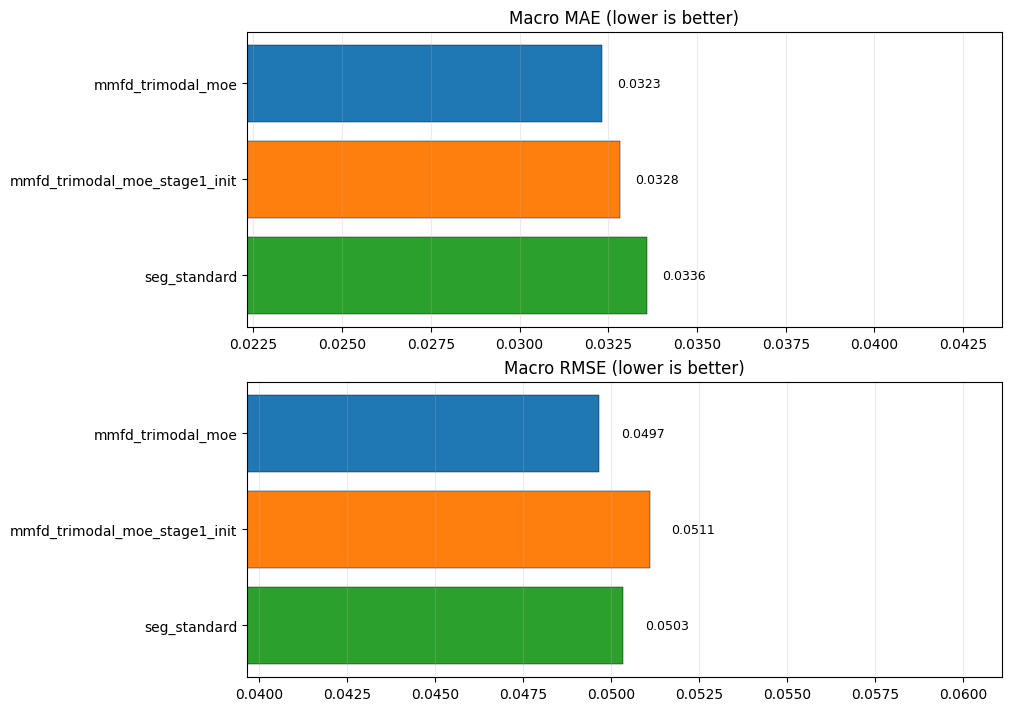

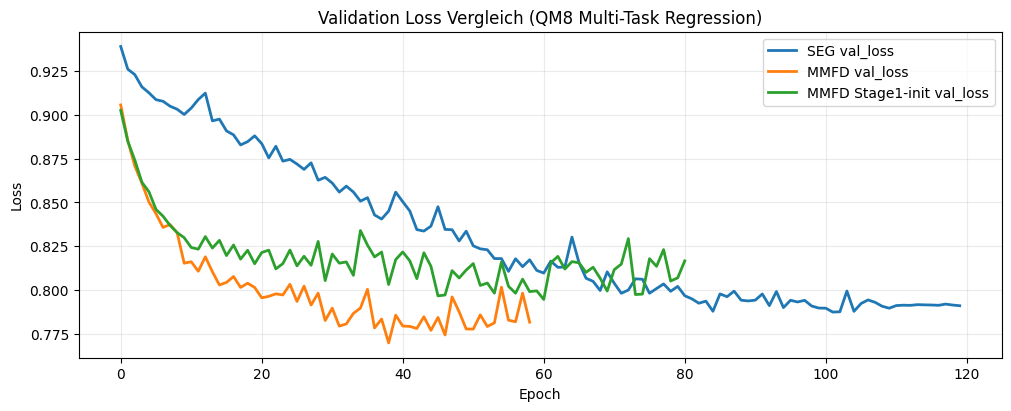

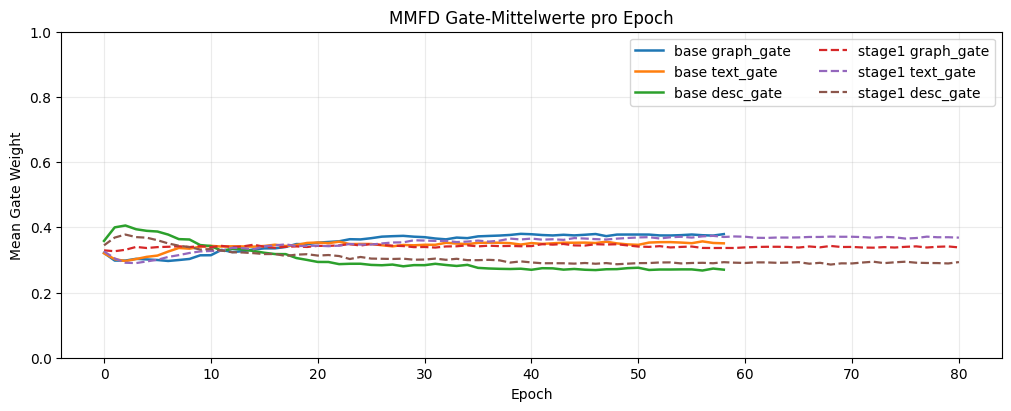

,task,seg_mae,seg_rmse,tame_mae,tame_rmse,tame_stage1_mae,tame_stage1_rmse
0,E1-CC2,0.031340,0.040556,0.030351,0.039627,0.031193,0.041082
1,E2-CC2,0.023137,0.031187,0.022738,0.030187,0.023313,0.031293
2,f1-CC2,0.030822,0.056436,0.029343,0.056753,0.030765,0.058621
3,f2-CC2,0.053062,0.080402,0.052407,0.081636,0.051048,0.082254
4,E1-PBE0,0.033932,0.043476,0.032539,0.042165,0.033633,0.043875
5,E2-PBE0,0.026708,0.035109,0.025860,0.033927,0.026723,0.035392
6,f1-PBE0,0.030430,0.055439,0.028516,0.055052,0.029568,0.056805
7,f2-PBE0,0.041001,0.063778,0.039488,0.062843,0.038824,0.064120
8,E1-PBE0,0.033932,0.043476,0.032538,0.042164,0.033633,0.043874
9,E2-PBE0,0.026708,0.035109,0.025861,0.033929,0.026722,0.035392


Saved summary CSV to: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\qm8_seg_vs_tame_multitask_summary.csv
Saved per-task CSV to: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\qm8_seg_vs_tame_multitask_per_task.csv


In [7]:
comparison_df = pd.DataFrame([
    {
        'dataset': 'qm8',
        'model': 'seg_standard',
        'best_val_loss': seg_best_val,
        'macro_mae': seg_metrics['macro_mae'],
        'macro_rmse': seg_metrics['macro_rmse'],
        'n_tasks_eval': seg_metrics['n_tasks_eval'],
    },
    {
        'dataset': 'qm8',
        'model': 'tame_trimodal_moe',
        'best_val_loss': tame_best_val,
        'macro_mae': tame_metrics['macro_mae'],
        'macro_rmse': tame_metrics['macro_rmse'],
        'n_tasks_eval': tame_metrics['n_tasks_eval'],
    },
    {
        'dataset': 'qm8',
        'model': 'tame_trimodal_moe_stage1_init',
        'best_val_loss': tame_stage1_best_val,
        'macro_mae': tame_stage1_metrics['macro_mae'],
        'macro_rmse': tame_stage1_metrics['macro_rmse'],
        'n_tasks_eval': tame_stage1_metrics['n_tasks_eval'],
    },
])
comparison_df = comparison_df.sort_values('macro_mae', ascending=True).reset_index(drop=True)
display(comparison_df)

metrics_to_plot = ['macro_mae', 'macro_rmse']
titles = ['Macro MAE (lower is better)', 'Macro RMSE (lower is better)']
palette = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(2, 1, figsize=(10, 7), constrained_layout=True)
for ax, metric_name, title in zip(axes, metrics_to_plot, titles):
    values = comparison_df[metric_name].values
    y = np.arange(len(comparison_df))
    bars = ax.barh(y, values, color=palette[:len(values)], edgecolor='black', linewidth=0.3)
    ax.set_yticks(y)
    ax.set_yticklabels(comparison_df['model'])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)
    xmin = max(0.0, float(np.nanmin(values) - 0.01))
    xmax = float(np.nanmax(values) + 0.01)
    ax.set_xlim(xmin, xmax)
    for bar, v in zip(bars, values):
        ax.text(v + (0.01 * max(xmax, 1e-6)), bar.get_y() + bar.get_height() / 2, f'{v:.4f}', va='center', fontsize=9)

plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
ax.plot(seg_hist.get('val_loss', []), label='SEG val_loss', linewidth=2)
ax.plot(tame_hist.get('val_loss', []), label='TAME val_loss', linewidth=2)
ax.plot(tame_stage1_hist.get('val_loss', []), label='TAME Stage1-init val_loss', linewidth=2)
ax.set_title('Validation Loss Vergleich (QM8 Multi-Task Regression)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

if all(k in tame_hist for k in ['graph_gate', 'text_gate', 'desc_gate']):
    fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
    ax.plot(tame_hist['graph_gate'], label='base graph_gate', linewidth=1.8)
    ax.plot(tame_hist['text_gate'], label='base text_gate', linewidth=1.8)
    ax.plot(tame_hist['desc_gate'], label='base desc_gate', linewidth=1.8)
    if all(k in tame_stage1_hist for k in ['graph_gate', 'text_gate', 'desc_gate']):
        ax.plot(tame_stage1_hist['graph_gate'], label='stage1 graph_gate', linewidth=1.6, linestyle='--')
        ax.plot(tame_stage1_hist['text_gate'], label='stage1 text_gate', linewidth=1.6, linestyle='--')
        ax.plot(tame_stage1_hist['desc_gate'], label='stage1 desc_gate', linewidth=1.6, linestyle='--')
    ax.set_title('TAME Gate-Mittelwerte pro Epoch')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean Gate Weight')
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.25)
    ax.legend(ncol=2)
    plt.show()

per_task_df = pd.DataFrame({
    'task': tasks,
    'seg_mae': seg_metrics['per_task_mae'],
    'seg_rmse': seg_metrics['per_task_rmse'],
    'tame_mae': tame_metrics['per_task_mae'],
    'tame_rmse': tame_metrics['per_task_rmse'],
    'tame_stage1_mae': tame_stage1_metrics['per_task_mae'],
    'tame_stage1_rmse': tame_stage1_metrics['per_task_rmse'],
})
display(per_task_df)

out_csv_summary = workspace_root / 'benchmarking' / 'results' / 'qm8_seg_vs_tame_multitask_summary.csv'
out_csv_tasks = workspace_root / 'benchmarking' / 'results' / 'qm8_seg_vs_tame_multitask_per_task.csv'
comparison_df.to_csv(out_csv_summary, index=False)
per_task_df.to_csv(out_csv_tasks, index=False)
print(f'Saved summary CSV to: {out_csv_summary}')
print(f'Saved per-task CSV to: {out_csv_tasks}')